## Resume Classification
### Business objective:
* **The document classification solution should significantly reduce the manual human effort in the HRM. It should achieve a higher level of accuracy and automation with minimal human intervention**

## 1. Import Library

In [1]:
import os
import re
import nltk
import spacy
import string
import textract
import pandas as pd
import seaborn as sns
from matplotlib import pylab
from matplotlib import pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer

import warnings
warnings.filterwarnings('ignore')

In [2]:
from wordcloud import WordCloud, STOPWORDS

In [3]:
os.listdir("C:\\Users\\Lenovo\\Downloads\\Resume_P29")

['PeopleSoft', 'React JS Developer', 'SQL Developer', 'Workday']

## 2. Exctract the Text from Dataset

In [4]:
import pypdf
import docx
import win32com.client as win32

In [5]:
def get_text(file_path):
    ext = file_path.lower()
    try:
        if ext.endswith('.pdf'):
            reader = pypdf.PdfReader(file_path)
            return " ".join([page.extract_text() for page in reader.pages if page.extract_text()])
        
        elif ext.endswith('.docx'):
            doc = docx.Document(file_path)
            return " ".join([p.text for p in doc.paragraphs])
        
        elif ext.endswith('.doc'):
            # Uses your installed MS Word to read old .doc files
            word = win32.gencache.EnsureDispatch('Word.Application')
            doc = word.Documents.Open(os.path.abspath(file_path))
            text = doc.Range().Text
            doc.Close()
            return text
    except Exception as e:
        return f"Error processing {file_path}: {e}"
    return ""

In [6]:
file_path1 = []
category1  = []
directory1 = "C:\\Users\\Lenovo\\Downloads\\Resume_P29\\PeopleSoft"

for i in os.listdir(directory1):
    if i.lower().endswith((".docx", ".pdf", ".doc")):
        full_path = os.path.join(directory1, i)
        
        resume_text = get_text(full_path)
        
        file_path1.append(resume_text)
        category1.append('PeopleSoft')

In [7]:
data1 = pd.DataFrame(data = file_path1 , columns = ['Raw_Details'])
data1['Category1'] = category1
data1

,Raw_Details,Category1
0,Anubhav Kumar Singh\t\t To work in a glob...,PeopleSoft
1,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...,PeopleSoft
2,PeopleSoft Database Administrator\r ...,PeopleSoft
3,Murali Experience Summary I have 6 years of...,PeopleSoft
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",PeopleSoft
5,PROFILE SUMMARY I have overall ...,PeopleSoft
6,PEOPLESOFT ADMINISTRATOR\r\r\rSRINIVAS.K \t\t\...,PeopleSoft
7,PeopleSoft Admin VARKALA VIKAS Career Object...,PeopleSoft
8,Vinod Akkala ...,PeopleSoft
9,PeopleSoft Admin/PeopleSoft DBA\r\rGanesh All...,PeopleSoft


In [8]:
file_path2 = []
category2  = []
directory2 = r"C:\Users\Lenovo\Downloads\Resume_P29\React JS Developer"

for i in os.listdir(directory2):
    if i.lower().endswith((".docx", ".pdf", ".doc")):
        full_path = os.path.join(directory2, i)
        
        resume_text = get_text(full_path)
        
        file_path2.append(resume_text)
        category2.append('React JS Developer')

In [9]:
data2 = pd.DataFrame(data = file_path2 , columns = ['Raw_Details'])
data2['Category2'] = category2
data2

,Raw_Details,Category2
0,Name: Ravali P ...,React JS Developer
1,SUSOVAN BAG Seeking a challenging po...,React JS Developer
2,Kanumuru Deepak Reddy CAREER OBJECTIVE: To...,React JS Developer
3,HARIPRIYA BATTINA Experience as UI Developer ...,React JS Developer
4,KAMALAKAR REDDY. A Linked In: https://www.lin...,React JS Developer
5,Naveen Sadhu Title: software developer\t\t\...,React JS Developer
6,\r\r PROFILE\rSearching for the opportunity ...,React JS Developer
7,PRAGNYA PATTNAIK Expertise: Having...,React JS Developer
8," 204,Sri geethika prestige,road number 10,b...",React JS Developer
9,\n Thirupathamma Balla SUMMARY: 2.8 year of ...,React JS Developer


In [10]:
file_path3 = []
category3  = []
directory3 = r"C:\Users\Lenovo\Downloads\Resume_P29\SQL Developer"

for i in os.listdir(directory3):
    if i.lower().endswith((".docx", ".pdf", ".doc")):
        full_path = os.path.join(directory3, i)
        
        resume_text = get_text(full_path)
        
        file_path3.append(resume_text)
        category3.append('SQL Developer')

In [11]:
data3 = pd.DataFrame(data = file_path3 , columns = ['Raw_Details'])
data3['Category3'] = category3
data3

,Raw_Details,Category3
0,ANIL KUMAR MADDUKURI \t\t SQL & MSBI Develope...,SQL Developer
1,Aradhana Tripathi Current Location: Gachibow...,SQL Developer
2,BUDDHA VAMSI ...,SQL Developer
3,KAMBALLA PRADEEP ...,SQL Developer
4,\r\r Hyderabad\rNazeer Basha\rSQL and Power...,SQL Developer
5,Resu...,SQL Developer
6,SQL DEVELOPER Name: - Bandi prem sai Willi...,SQL Developer
7,SQL SER...,SQL Developer
8,SQL SER...,SQL Developer
9,RAJU PAVANA KUMARI Professional Summary: Ha...,SQL Developer


In [12]:
file_path4 = []
category4  = []
directory4 = r"C:\Users\Lenovo\Downloads\Resume_P29\Workday"

for i in os.listdir(directory4):
    if i.lower().endswith((".docx", ".pdf", ".doc")):
        full_path = os.path.join(directory4, i)
        
        resume_text = get_text(full_path)
        
        file_path4.append(resume_text)
        category4.append('Workday')

In [13]:
data4 = pd.DataFrame(data = file_path4 , columns = ['Raw_Details'])
data4['Category4'] = category4
data4

,Raw_Details,Category4
0,Chinna Subbarayudu M DOB: 06th March 1994 Nati...,Workday
1,\t Name : Gopi Krishna Reddy \t\t ...,Workday
2,Hari Krishna M\r\r\rSummary:\rA result oriente...,Workday
3,Harikrishna Akula ...,Workday
4,HIMA.MENDU\r \r\rCareer Objective\rTo continu...,Workday
5,...,Workday
6,\t\t\t\t\t\t\tName:\tJ. Sumanth Royal.\r\t\rP...,Workday
7,JYOTI VERMA\t\t\t\t\t 3 years of Experien...,Workday
8,\t\t\t\t\tMadeeswar A\r\t\r\t\rPROFILE SUMMARY...,Workday
9,Mooraboyina Guravaiah Workday Integration Sp...,Workday


## 3. Create a DataFrame

In [14]:
resume_data = pd.concat([data1,data2, data3, data4], ignore_index = True)
resume_data

,Raw_Details,Category1,Category2,Category3,Category4
0,Anubhav Kumar Singh\t\t To work in a glob...,PeopleSoft,NaN,NaN,NaN
1,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...,PeopleSoft,NaN,NaN,NaN
2,PeopleSoft Database Administrator\r ...,PeopleSoft,NaN,NaN,NaN
3,Murali Experience Summary I have 6 years of...,PeopleSoft,NaN,NaN,NaN
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",PeopleSoft,NaN,NaN,NaN
...,...,...,...,...,...
74,\tWorkday Integration Consultant\r\rName ...,NaN,NaN,NaN,Workday
75,Seeking suitable positions in Workday HCM as ...,NaN,NaN,NaN,Workday
76,WORKDAY | HCM | FCM Name \t\t: Kumar S.S Role...,NaN,NaN,NaN,Workday
77,Venkateswarlu.B\t\t\t\t\t\t\t\tWorkday Consult...,NaN,NaN,NaN,Workday


### 3.1 Merge all Unnecessary column in One Column

In [15]:
resume_data['Category'] = category1 + category2 + category3 + category4
resume_data

,Raw_Details,Category1,Category2,Category3,Category4,Category
0,Anubhav Kumar Singh\t\t To work in a glob...,PeopleSoft,NaN,NaN,NaN,PeopleSoft
1,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...,PeopleSoft,NaN,NaN,NaN,PeopleSoft
2,PeopleSoft Database Administrator\r ...,PeopleSoft,NaN,NaN,NaN,PeopleSoft
3,Murali Experience Summary I have 6 years of...,PeopleSoft,NaN,NaN,NaN,PeopleSoft
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",PeopleSoft,NaN,NaN,NaN,PeopleSoft
...,...,...,...,...,...,...
74,\tWorkday Integration Consultant\r\rName ...,NaN,NaN,NaN,Workday,Workday
75,Seeking suitable positions in Workday HCM as ...,NaN,NaN,NaN,Workday,Workday
76,WORKDAY | HCM | FCM Name \t\t: Kumar S.S Role...,NaN,NaN,NaN,Workday,Workday
77,Venkateswarlu.B\t\t\t\t\t\t\t\tWorkday Consult...,NaN,NaN,NaN,Workday,Workday


In [16]:
resume_data.drop(['Category1', 'Category2', 'Category3', 'Category4'], axis = 1, inplace = True)
resume_data = resume_data[["Category", "Raw_Details"]]

### 3.2 Final Dataset

In [17]:
resume_data

,Category,Raw_Details
0,PeopleSoft,Anubhav Kumar Singh\t\t To work in a glob...
1,PeopleSoft,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...
2,PeopleSoft,PeopleSoft Database Administrator\r ...
3,PeopleSoft,Murali Experience Summary I have 6 years of...
4,PeopleSoft,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo..."
...,...,...
74,Workday,\tWorkday Integration Consultant\r\rName ...
75,Workday,Seeking suitable positions in Workday HCM as ...
76,Workday,WORKDAY | HCM | FCM Name \t\t: Kumar S.S Role...
77,Workday,Venkateswarlu.B\t\t\t\t\t\t\t\tWorkday Consult...


### About the dataset

In [18]:
file_path   = r"C:\Users\Lenovo\Downloads\Resume_P29"
doc_file    = []
pdf_file    = []
docx_file   = []
folder_name = []

for folder in os.listdir(file_path):
    folder_path = os.path.join(file_path, folder)
    for file in os.listdir(folder_path):
        if file.endswith('.doc'):
            doc_file.append(file)
            folder_name.append(folder)
        elif file.endswith('.docx'):
            docx_file.append(file)
            folder_name.append(folder)
        else:
            pdf_file.append(file)
            folder_name.append(folder)

In [19]:
print('Number of .doc Files  = {}'.format(len(doc_file)),'\n'
      'Number of .pdf Files  = {}'.format(len(pdf_file)),'\n'
      'Number of .docx Files = {}'.format(len(docx_file)))

Number of .doc Files  = 26 
Number of .pdf Files  = 1 
Number of .docx Files = 52


In [20]:
print("Total Number of Files = ", len(docx_file)+len(doc_file)+len(pdf_file))

Total Number of Files =  79


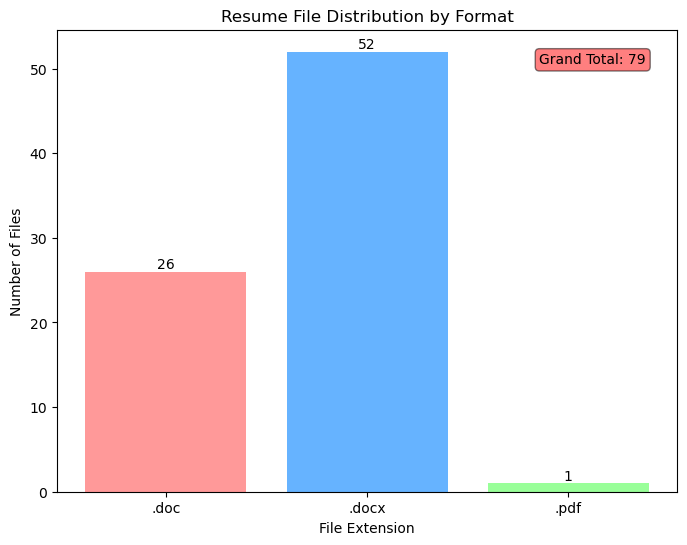

In [21]:
file_types = ['.doc', '.docx', '.pdf']
counts = [len(doc_file), len(docx_file), len(pdf_file)]
total_files = sum(counts)
colors = ['#ff9999', '#66b3ff', '#99ff99']

plt.figure(figsize=(8, 6))
bars = plt.bar(file_types, counts, color=colors)
plt.xlabel('File Extension')
plt.ylabel('Number of Files')
plt.title('Resume File Distribution by Format')
plt.bar_label(bars)
plt.text(0.95, 0.95, f'Grand Total: {total_files}', 
         transform=plt.gca().transAxes, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))
plt.show()

### 3.3 Save the CSV File

In [22]:
resume_data.to_csv('Raw_Resume.csv', index=False)

## 4. Data Understanding

In [23]:
resume_data = pd.read_csv("Raw_Resume.csv")
resume_data

,Category,Raw_Details
0,PeopleSoft,Anubhav Kumar Singh\t\t To work in a glob...
1,PeopleSoft,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...
2,PeopleSoft,PeopleSoft Database Administrator\r ...
3,PeopleSoft,Murali Experience Summary I have 6 years of...
4,PeopleSoft,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo..."
...,...,...
74,Workday,\tWorkday Integration Consultant\r\rName ...
75,Workday,Seeking suitable positions in Workday HCM as ...
76,Workday,WORKDAY | HCM | FCM Name \t\t: Kumar S.S Role...
77,Workday,Venkateswarlu.B\t\t\t\t\t\t\t\tWorkday Consult...


In [24]:
resume_data.sample(5)

,Category,Raw_Details
18,PeopleSoft,Tanna Sujatha OBJECTIVE Seeking a challeng...
59,Workday,\t Name : Gopi Krishna Reddy \t\t ...
53,SQL Developer,RAJU PAVANA KUMARI Professional Summary: Ha...
34,React JS Developer,Kotani Durga Prasad Objective: Aspirant for...
32,React JS Developer,Ui-Developer/ React JS Developer NAME: KRISH...


In [25]:
resume_data.shape

(79, 2)

In [26]:
resume_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Category     79 non-null     object
 1   Raw_Details  79 non-null     object
dtypes: object(2)
memory usage: 1.4+ KB


In [27]:
resume_data.isnull().sum()

Category       0
Raw_Details    0
dtype: int64

In [28]:
resume_data['Category'].unique()

array(['PeopleSoft', 'React JS Developer', 'SQL Developer', 'Workday'],
      dtype=object)

In [29]:
resume_data['Category'].value_counts()

Category
React JS Developer    24
Workday               21
PeopleSoft            20
SQL Developer         14
Name: count, dtype: int64

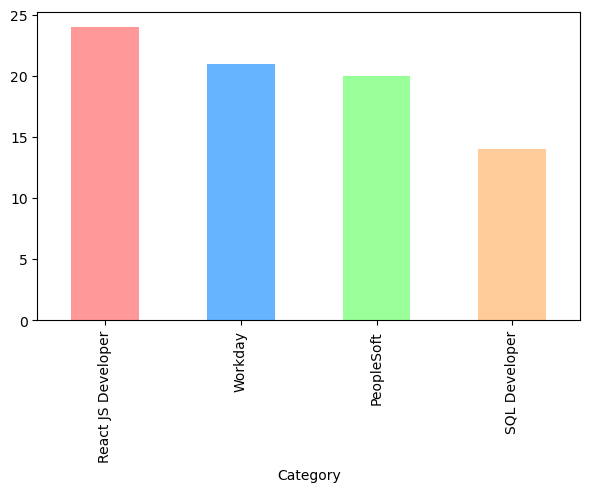

In [30]:
#plt.style.use('ggplot')
plt.figure(figsize=(7,4))
resume_data['Category'].value_counts().plot(kind='bar',color =  ['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.show()

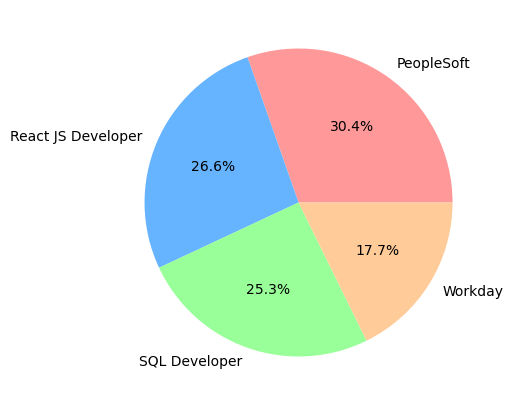

In [31]:
import numpy as np
counts = resume_data['Category'].value_counts()
labels = resume_data['Category'].unique()
plt.figure(figsize=(12,5))
plt.pie(counts,labels= labels, autopct = '%1.1f%%',colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.show()

#### 4.1 Number of Words in each Resume

In [32]:
resume_data['Word_Count'] = resume_data['Raw_Details'].apply(lambda x: len(str(x).split(" ")))
resume_data[['Raw_Details','Word_Count']].head()

,Raw_Details,Word_Count
0,Anubhav Kumar Singh\t\t To work in a glob...,1119
1,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...,1431
2,PeopleSoft Database Administrator\r ...,1346
3,Murali Experience Summary I have 6 years of...,607
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",670


### 4.2 Number of Characters

In [33]:
resume_data['Char_Count'] = resume_data['Raw_Details'].str.len() ## this also includes spaces
resume_data[['Raw_Details','Char_Count']].head()

,Raw_Details,Char_Count
0,Anubhav Kumar Singh\t\t To work in a glob...,7256
1,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...,8047
2,PeopleSoft Database Administrator\r ...,6768
3,Murali Experience Summary I have 6 years of...,3981
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",5076


### 4.3 Number of Stopwords

In [34]:
from nltk.corpus import stopwords
stop = stopwords.words('english')
resume_data['Stopwords'] = resume_data['Raw_Details'].apply(lambda x: len([x for x in x.split() if x in stop]))
resume_data[['Raw_Details','Stopwords']].head()

,Raw_Details,Stopwords
0,Anubhav Kumar Singh\t\t To work in a glob...,187
1,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...,186
2,PeopleSoft Database Administrator\r ...,177
3,Murali Experience Summary I have 6 years of...,111
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",123


### 4.4 Number of Numerics

In [35]:
resume_data['Numerics'] = resume_data['Raw_Details'].apply(lambda x: len([x for x in x.split() if x.isdigit()]))
resume_data[['Raw_Details','Numerics']].head()

,Raw_Details,Numerics
0,Anubhav Kumar Singh\t\t To work in a glob...,3
1,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...,6
2,PeopleSoft Database Administrator\r ...,4
3,Murali Experience Summary I have 6 years of...,1
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",5


In [36]:
resume_data

,Category,Raw_Details,Word_Count,Char_Count,Stopwords,Numerics
0,PeopleSoft,Anubhav Kumar Singh\t\t To work in a glob...,1119,7256,187,3
1,PeopleSoft,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...,1431,8047,186,6
2,PeopleSoft,PeopleSoft Database Administrator\r ...,1346,6768,177,4
3,PeopleSoft,Murali Experience Summary I have 6 years of...,607,3981,111,1
4,PeopleSoft,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",670,5076,123,5
...,...,...,...,...,...,...
74,Workday,\tWorkday Integration Consultant\r\rName ...,904,6967,197,3
75,Workday,Seeking suitable positions in Workday HCM as ...,1064,6324,191,6
76,Workday,WORKDAY | HCM | FCM Name \t\t: Kumar S.S Role...,1124,7309,228,1
77,Workday,Venkateswarlu.B\t\t\t\t\t\t\t\tWorkday Consult...,1027,6627,193,7


## Text Cleaning using NLP

In [37]:
resume_data['Raw_Details'][0]

'  Anubhav Kumar Singh\t\t    To work in a globally competitive environment on    challenging assignments that shall yield the    twin benefits of the job satisfaction and a steady-paced    professional growth.                Professional Experience   06/2019 - Current\tHCL\t\t\t\t\t\t\t\t\t\t \t\t\tCurrent Role: System Admin Offshore \t\t\tSkills : Shell Scripting, Linux , PeopleSoft Administration , Github  Managing PeopleSoft HCM and PeopleSoft FSCM production environments along with support environments installed on Linux and Windows OS. Involved in Day to Day activities such as Project Migration, Database Refresh, System admin changes, Tax updates etc. Troubleshooting of various servers like application servers, Web Servers, Process Scheduler Servers. Applying Tuxedo and WebLogic Middleware CPU patches for various applications. Working on shell scripting used as integration method for exchange of files to external systems Installation and troubleshooting of 2-tier setup as per req

In [38]:
def clean(sentence):
    sentence = str(sentence)
    sentence = sentence.lower()
    sentence = sentence.replace('{html}',"") 
    cleanr = re.compile('<.*?>')
    cleantext = re.sub(cleanr, '', sentence)
    rem_url = re.sub(r'http\S+', '',cleantext)
    rem_num = re.sub('[0-9]+', '', rem_url)
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(rem_num)  
    filtered_words = [w for w in tokens if len(w) > 2 if not w in stopwords.words('english')]

    return " ".join(filtered_words)

In [39]:
resume_data = pd.read_csv('Raw_Resume.csv')
resume_data['Resume_Details'] = resume_data.Raw_Details.apply(lambda x: clean(x))

In [40]:
resume_data['Resume_Details'][0]

'anubhav kumar singh work globally competitive environment challenging assignments shall yield twin benefits job satisfaction steady paced professional growth professional experience current hcl current role system admin offshore skills shell scripting linux peoplesoft administration github managing peoplesoft hcm peoplesoft fscm production environments along support environments installed linux windows involved day day activities project migration database refresh system admin changes tax updates etc troubleshooting various servers like application servers web servers process scheduler servers applying tuxedo weblogic middleware cpu patches various applications working shell scripting used integration method exchange files external systems installation troubleshooting tier setup per requirement reviewing vulnerabilities reported security teams renewal ssl weblogic vulnerability remediation whenever vulnerability report rmis team worked pum peoplesoft update manager installation dpk wo

In [41]:
resume_data.head()

,Category,Raw_Details,Resume_Details
0,PeopleSoft,Anubhav Kumar Singh\t\t To work in a glob...,anubhav kumar singh work globally competitive ...
1,PeopleSoft,\r\r\r\r\r\r\t\r\rProfile Summary:\t\t\t\t\t\t...,profile summary years experience implementing ...
2,PeopleSoft,PeopleSoft Database Administrator\r ...,peoplesoft database administrator gangareddy p...
3,PeopleSoft,Murali Experience Summary I have 6 years of...,murali experience summary years experience wor...
4,PeopleSoft,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",priyanka ramadoss mountpleasant coonoor nilgir...


#### Save the clean data in csv file

In [42]:
resume_data.drop(['Raw_Details'], axis = 1, inplace = True)
resume_data

,Category,Resume_Details
0,PeopleSoft,anubhav kumar singh work globally competitive ...
1,PeopleSoft,profile summary years experience implementing ...
2,PeopleSoft,peoplesoft database administrator gangareddy p...
3,PeopleSoft,murali experience summary years experience wor...
4,PeopleSoft,priyanka ramadoss mountpleasant coonoor nilgir...
...,...,...
74,Workday,workday integration consultant name sri krishn...
75,Workday,seeking suitable positions workday hcm techno ...
76,Workday,workday hcm fcm name kumar role workday consul...
77,Workday,venkateswarlu workday consultant years experie...


In [43]:
resume_data.to_csv('Cleaned_Resumes.csv', index = False)

In [44]:
resume_data = pd.read_csv('Cleaned_Resumes.csv')
resume_data

,Category,Resume_Details
0,PeopleSoft,anubhav kumar singh work globally competitive ...
1,PeopleSoft,profile summary years experience implementing ...
2,PeopleSoft,peoplesoft database administrator gangareddy p...
3,PeopleSoft,murali experience summary years experience wor...
4,PeopleSoft,priyanka ramadoss mountpleasant coonoor nilgir...
...,...,...
74,Workday,workday integration consultant name sri krishn...
75,Workday,seeking suitable positions workday hcm techno ...
76,Workday,workday hcm fcm name kumar role workday consul...
77,Workday,venkateswarlu workday consultant years experie...


## 6. Named Entity Recognition (NER)

In [45]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [46]:
oneSetOfStopWords = set(stopwords.words('english')+['``',"''"])
totalWords =[]
Sentences = resume_data['Resume_Details'].values
cleanedSentences = ""
for records in Sentences:
    cleanedText = clean(records)
    cleanedSentences += cleanedText
    requiredWords = nltk.word_tokenize(cleanedText)
    for word in requiredWords:
        if word not in oneSetOfStopWords and word not in string.punctuation:
            totalWords.append(word)
    
wordfreqdist = nltk.FreqDist(totalWords)
mostcommon = wordfreqdist.most_common(50)
print(mostcommon)

[('experience', 575), ('peoplesoft', 440), ('application', 396), ('workday', 392), ('using', 383), ('server', 338), ('reports', 320), ('data', 319), ('project', 310), ('business', 264), ('sql', 244), ('process', 233), ('database', 230), ('web', 229), ('worked', 219), ('knowledge', 209), ('involved', 188), ('integrations', 187), ('client', 186), ('like', 179), ('integration', 177), ('support', 175), ('system', 172), ('tools', 172), ('hcm', 166), ('development', 165), ('good', 164), ('creating', 161), ('team', 159), ('working', 157), ('design', 152), ('skills', 151), ('technical', 151), ('people', 150), ('servers', 149), ('testing', 149), ('report', 146), ('created', 145), ('various', 144), ('responsibilities', 143), ('services', 139), ('environment', 135), ('production', 133), ('react', 132), ('issues', 131), ('oracle', 129), ('role', 127), ('management', 127), ('security', 126), ('eib', 125)]


## 7. Parts Of Speech (POS) Tagging

In [47]:
nlp = spacy.load('en_core_web_lg')

one_block = cleanedSentences[1300:5200]
doc_block = nlp(one_block)
spacy.displacy.render(doc_block, style= 'ent', jupyter= True)

In [48]:
for token in doc_block[:30]:
    print(token,token.pos_)

upgrade VERB
project NOUN
migration NOUN
applications NOUN
ntt PROPN
cloud PROPN
premises NOUN
aws PROPN
cloud PROPN
worked VERB
shell NOUN
scripting NOUN
various ADJ
application NOUN
requirement NOUN
working VERB
ansible PROPN
jenkins PROPN
automated VERB
start PROPN
stop VERB
various ADJ
activities NOUN
application VERB
basic ADJ
knowledge NOUN
docker NOUN
applying VERB
ssl PROPN
certificates NOUN


In [49]:
one_block = cleanedSentences
doc_block = nlp(one_block)
nouns_verbs = [token.text for token in doc_block if token.pos_ in ('NOUN','VERB')]
print(nouns_verbs[:250])

['work', 'environment', 'challenging', 'assignments', 'yield', 'benefits', 'job', 'satisfaction', 'paced', 'growth', 'experience', 'role', 'system', 'admin', 'skills', 'shell', 'scripting', 'managing', 'fscm', 'production', 'environments', 'support', 'environments', 'installed', 'windows', 'involved', 'day', 'day', 'activities', 'project', 'migration', 'database', 'refresh', 'system', 'admin', 'changes', 'tax', 'updates', 'troubleshooting', 'servers', 'application', 'servers', 'web', 'servers', 'process', 'scheduler', 'servers', 'applying', 'tuxedo', 'weblogic', 'middleware', 'cpu', 'patches', 'applications', 'working', 'shell', 'scripting', 'used', 'integration', 'method', 'exchange', 'files', 'systems', 'installation', 'troubleshooting', 'tier', 'setup', 'requirement', 'reviewing', 'vulnerabilities', 'reported', 'security', 'teams', 'renewal', 'weblogic', 'vulnerability', 'remediation', 'vulnerability', 'report', 'team', 'worked', 'update', 'manager', 'installation', 'working', 'know

In [50]:
cv = CountVectorizer()
X = cv.fit_transform(nouns_verbs)
sum_words = X.sum(axis=0)

words_freq = [(word,sum_words[0,idx]) for word, idx in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

wd_df = pd.DataFrame(words_freq)
wd_df.columns = ['Words','Count']
wd_df[0:15]

,Words,Count
0,experience,529
1,application,391
2,using,382
3,reports,320
4,data,298
5,workday,296
6,project,285
7,business,253
8,process,231
9,web,229


#### Reading a resume file

In [51]:
import docx2txt
def extract_text_from_docx(docx_path):
    txt = docx2txt.process(docx_path)
    if txt:
        return txt.replace('\t', ' ')
    return None
 
print(extract_text_from_docx(r'C:\Users\Lenovo\Downloads\Resume_P29\React JS Developer\React Developer_Haripriya.docx'))

HARIPRIYA BATTINA 

Experience as UI Developer in Reactjs, JavaScript. 

Phone: +91 9908576950 

Gmail: haripriyabattini@gmai.com 

Location: Visakhapatnam 

JOB OBJECTIVE ● Looking for a challenging role to put my experience in various aspects of technology with an objective to be a leading source of information and guidance concerning th

technological requirements. 

● Want to be a part of a reputed organization that allows me to effectively use my 

technical skills in the real world for overall growth of organization and my 

professional career. 

WORK EXPERIENCE EDUCATION 

1. Associate UI Developr 

Company: Blue Yonder, Hyderabad. 

● Work Done On “COPERNICUS” Project. 

● The Main Moto of this project is, it is GTM (Go To Market) Portal which is specially designed for demo teams to shower case Blue Yonder Products and Features for Customers and Partners 

● Technologies: HTML, CSS, React JS. 

● IDE: VS Code. 

● Methodologies: Agile. 

JOB RESPONSIBILITIES: 

● Involved Desi

## 5. Data Exploration

In [52]:
resume_data = pd.read_csv('Cleaned_Resumes.csv')
resume_data

,Category,Resume_Details
0,PeopleSoft,anubhav kumar singh work globally competitive ...
1,PeopleSoft,profile summary years experience implementing ...
2,PeopleSoft,peoplesoft database administrator gangareddy p...
3,PeopleSoft,murali experience summary years experience wor...
4,PeopleSoft,priyanka ramadoss mountpleasant coonoor nilgir...
...,...,...
74,Workday,workday integration consultant name sri krishn...
75,Workday,seeking suitable positions workday hcm techno ...
76,Workday,workday hcm fcm name kumar role workday consul...
77,Workday,venkateswarlu workday consultant years experie...


### 5.1 N-grams
* **N-grams analyses are often used to see which words often show up together.**

In [53]:
from textblob import TextBlob

In [54]:
TextBlob(resume_data['Resume_Details'][1]).ngrams(1)[:20]

[WordList(['profile']),
 WordList(['summary']),
 WordList(['years']),
 WordList(['experience']),
 WordList(['implementing']),
 WordList(['upgrading']),
 WordList(['supporting']),
 WordList(['peoplesoft']),
 WordList(['database']),
 WordList(['administration']),
 WordList(['including']),
 WordList(['human']),
 WordList(['capital']),
 WordList(['management']),
 WordList(['hcm']),
 WordList(['financials']),
 WordList(['campus']),
 WordList(['solutions']),
 WordList(['portal']),
 WordList(['ihub'])]

In [55]:
TextBlob(resume_data['Resume_Details'][1]).ngrams(2)[:20]

[WordList(['profile', 'summary']),
 WordList(['summary', 'years']),
 WordList(['years', 'experience']),
 WordList(['experience', 'implementing']),
 WordList(['implementing', 'upgrading']),
 WordList(['upgrading', 'supporting']),
 WordList(['supporting', 'peoplesoft']),
 WordList(['peoplesoft', 'database']),
 WordList(['database', 'administration']),
 WordList(['administration', 'including']),
 WordList(['including', 'human']),
 WordList(['human', 'capital']),
 WordList(['capital', 'management']),
 WordList(['management', 'hcm']),
 WordList(['hcm', 'financials']),
 WordList(['financials', 'campus']),
 WordList(['campus', 'solutions']),
 WordList(['solutions', 'portal']),
 WordList(['portal', 'ihub']),
 WordList(['ihub', 'expertise'])]

In [56]:
TextBlob(resume_data['Resume_Details'][1]).ngrams(3)[:20]

[WordList(['profile', 'summary', 'years']),
 WordList(['summary', 'years', 'experience']),
 WordList(['years', 'experience', 'implementing']),
 WordList(['experience', 'implementing', 'upgrading']),
 WordList(['implementing', 'upgrading', 'supporting']),
 WordList(['upgrading', 'supporting', 'peoplesoft']),
 WordList(['supporting', 'peoplesoft', 'database']),
 WordList(['peoplesoft', 'database', 'administration']),
 WordList(['database', 'administration', 'including']),
 WordList(['administration', 'including', 'human']),
 WordList(['including', 'human', 'capital']),
 WordList(['human', 'capital', 'management']),
 WordList(['capital', 'management', 'hcm']),
 WordList(['management', 'hcm', 'financials']),
 WordList(['hcm', 'financials', 'campus']),
 WordList(['financials', 'campus', 'solutions']),
 WordList(['campus', 'solutions', 'portal']),
 WordList(['solutions', 'portal', 'ihub']),
 WordList(['portal', 'ihub', 'expertise']),
 WordList(['ihub', 'expertise', 'installation'])]

In [57]:
resume_data['Resume_Details']

0     anubhav kumar singh work globally competitive ...
1     profile summary years experience implementing ...
2     peoplesoft database administrator gangareddy p...
3     murali experience summary years experience wor...
4     priyanka ramadoss mountpleasant coonoor nilgir...
                            ...                        
74    workday integration consultant name sri krishn...
75    seeking suitable positions workday hcm techno ...
76    workday hcm fcm name kumar role workday consul...
77    venkateswarlu workday consultant years experie...
78    vinay kumar workday functional consultant expe...
Name: Resume_Details, Length: 79, dtype: object

### 5.2 Top 20 most used words in Resumes
* **Using CountVectorizer**

In [58]:
countvec = CountVectorizer(stop_words=stopwords.words('english'), ngram_range=(1,2))
ngrams = countvec.fit_transform(resume_data['Resume_Details']) # matrix of ngrams
count_values = ngrams.toarray().sum(axis=0) # count frequency of ngrams

vocab = countvec.vocabulary_ # list of ngrams
df_ngram = pd.DataFrame(sorted([(count_values[i],k) for k, i in vocab.items()],
                               reverse=True)).rename(columns={0: 'Frequency', 1:'Unigram_Bigram'})

In [59]:
df_ngram.head(20)

,Frequency,Unigram_Bigram
0,575,experience
1,440,peoplesoft
2,396,application
3,392,workday
4,383,using
5,338,server
6,320,reports
7,319,data
8,310,project
9,264,business


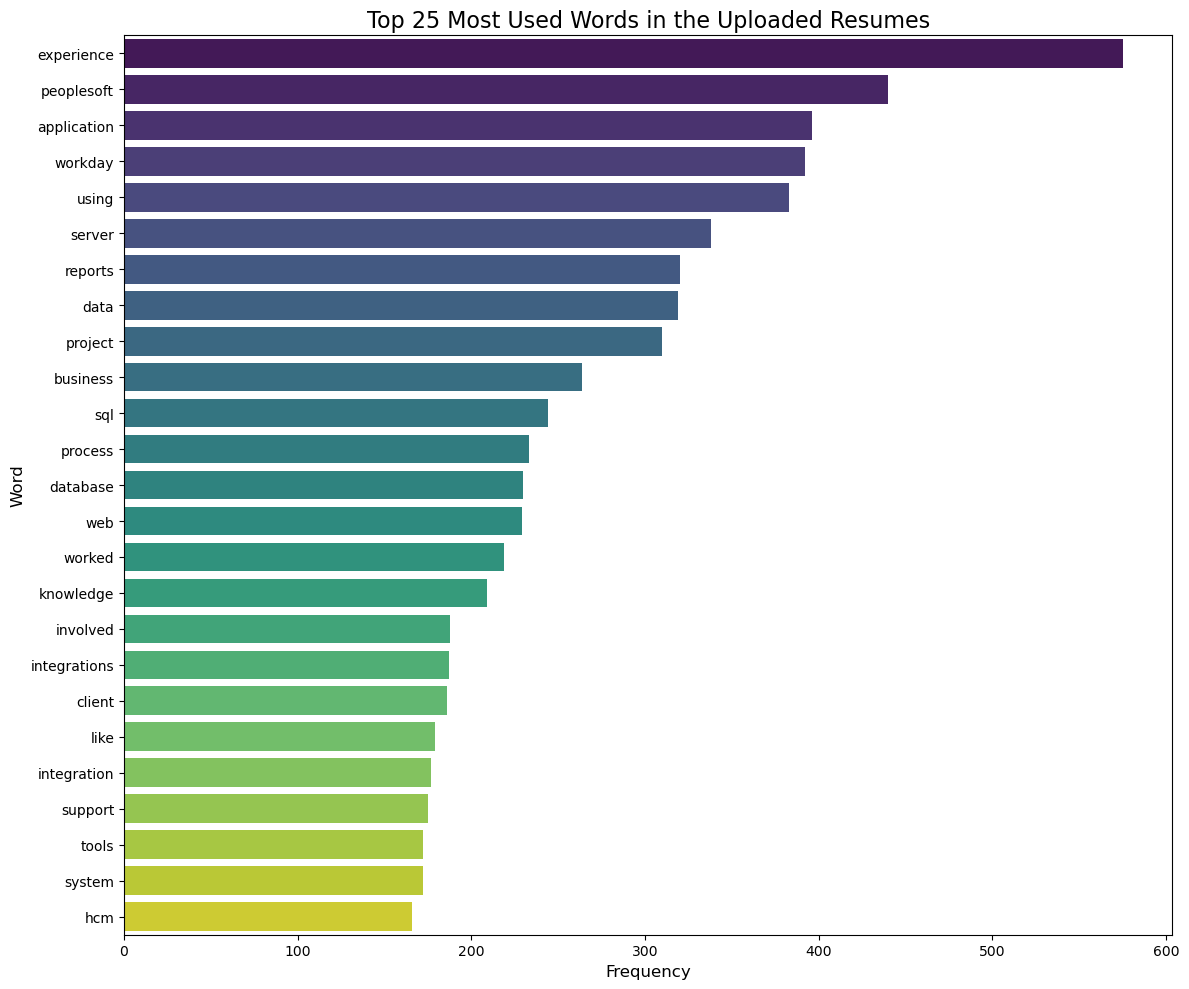

In [60]:
plt.figure(figsize=(12, 10))
sns.barplot(x='Frequency', y='Unigram_Bigram', data=df_ngram.head(25), palette='viridis')
plt.title('Top 25 Most Used Words in the Uploaded Resumes', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()
plt.show()

## Model Building

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

### 3. Data Preprocessing
### 3.1 LabelEncoder

In [62]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the Category column
resume_data['Category_Label'] = le.fit_transform(resume_data['Category'])

# Display the mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'PeopleSoft': np.int64(0), 'React JS Developer': np.int64(1), 'SQL Developer': np.int64(2), 'Workday': np.int64(3)}


In [63]:
resume_data

,Category,Resume_Details,Category_Label
0,PeopleSoft,anubhav kumar singh work globally competitive ...,0
1,PeopleSoft,profile summary years experience implementing ...,0
2,PeopleSoft,peoplesoft database administrator gangareddy p...,0
3,PeopleSoft,murali experience summary years experience wor...,0
4,PeopleSoft,priyanka ramadoss mountpleasant coonoor nilgir...,0
...,...,...,...
74,Workday,workday integration consultant name sri krishn...,3
75,Workday,seeking suitable positions workday hcm techno ...,3
76,Workday,workday hcm fcm name kumar role workday consul...,3
77,Workday,venkateswarlu workday consultant years experie...,3


In [64]:
resume_data.describe()

,Category_Label
count,79.000000
mean,1.455696
std,1.141271
min,0.000000
25%,0.500000
50%,1.000000
75%,3.000000
max,3.000000


#### train_test

In [65]:
x = resume_data['Resume_Details'].values
y = resume_data['Category'].values

In [66]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=45, test_size=0.25,stratify=y)
x_train.shape, x_test.shape

((59,), (20,))

In [67]:
tfidf = TfidfVectorizer(sublinear_tf=True, stop_words='english')
X = tfidf.fit_transform(resume_data['Resume_Details'])
y = resume_data['Category_Label']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((63, 4175), (16, 4175))

#### Model Initialization

In [69]:
models = {
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Multinomial NB": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [70]:
import pandas as pd

# 1. Initialize an empty list to store results
results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    score = accuracy_score(y_test, predictions)
    train = model.score(X_train, y_train)
    
    # 2. Add row data as a dictionary to the list
    results_list.append({
        "Model": name, 
        "Accuracy Score": score, 
        "Training Score": train
    })

# 3. Create the final DataFrame from the list of dictionaries
result = pd.DataFrame(results_list)
result


,Model,Accuracy Score,Training Score
0,K-Nearest Neighbors,0.9375,0.984127
1,Logistic Regression,0.9375,1.000000
2,Random Forest,1.0000,1.000000
3,SVM,0.9375,1.000000
4,Multinomial NB,0.8750,1.000000
5,Decision Tree,1.0000,1.000000


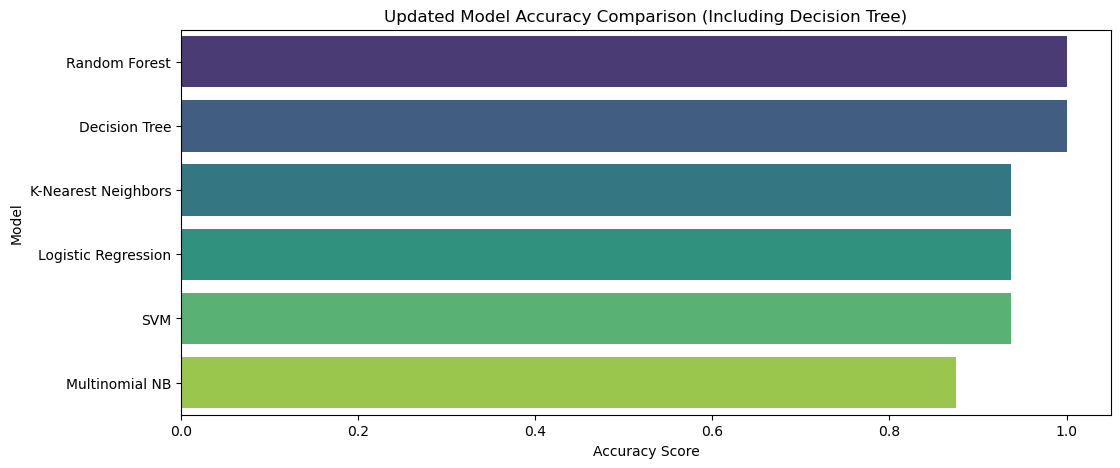

In [75]:
plt.figure(figsize=(12, 5))
sns.barplot(x='Accuracy Score', y='Model', data=result.sort_values(by='Accuracy Score', ascending=False), palette='viridis')
plt.title("Updated Model Accuracy Comparison (Including Decision Tree)")
plt.show()

In [77]:
RF =RandomForestClassifier(random_state=42)
RF.fit(X_train,y_train)
RF_pred = RF.predict(X_test)
print(RF.score(X_train,y_train))
print(RF.score(X_test,y_test))

1.0
1.0


In [78]:
y_test,RF_pred

(30    1
 0     0
 22    1
 31    1
 18    0
 28    1
 10    0
 70    3
 4     0
 12    0
 49    2
 33    1
 67    3
 35    1
 68    3
 45    2
 Name: Category_Label, dtype: int64,
 array([1, 0, 1, 1, 0, 1, 0, 3, 0, 0, 2, 1, 3, 1, 3, 2]))

In [79]:
import pandas as pd

# Use .values to ensure it works regardless of whether y_test is a Series or Array
final_result = pd.DataFrame({
    'Actual': y_test.values if hasattr(y_test, 'values') else y_test.flatten(),
    'Predicted': RF_pred
})

# Display a random sample of 10 rows
final_result.sample(10)


,Actual,Predicted
5,1,1
7,3,3
8,0,0
15,2,2
10,2,2
3,1,1
0,1,1
12,3,3
2,1,1
9,0,0


In [80]:
best_model = models["Random Forest"]

In [81]:
best_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
import joblib

# Save the winning model
joblib.dump(best_model, 'resume_classifier.pkl')

# Save the TF-IDF Vectorizer (Required to transform new input text)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Save the Label Encoder (Required to map numbers back to Job Titles)
joblib.dump(le, 'label_encoder.pkl')

print("Deployment files saved: resume_classifier.pkl, tfidf_vectorizer.pkl, label_encoder.pkl")

Deployment files saved: resume_classifier.pkl, tfidf_vectorizer.pkl, label_encoder.pkl
